# Phân cụm dữ liệu

Phân cụm được sử dụng để nhóm các mẫu nước có đặc điểm hóa học tương tự nhau.

Trong bài này chúng ta sử dụng thuật toán K-Means để phân cụm dữ liệu sau khi chuẩn hóa.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/water_clean.csv")

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [2]:
from sklearn.preprocessing import StandardScaler

features = df.drop("Potability", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

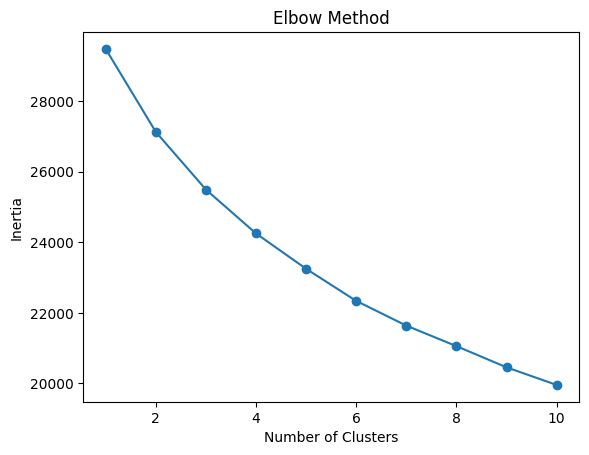

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Phương pháp Elbow được sử dụng để xác định số cụm tối ưu.
Dựa trên biểu đồ, giá trị K = 3 được chọn cho bài toán này.

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [5]:
df.groupby("Cluster").mean()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
Cluster,,,,,,,,,,
0,7.191339,208.715880,18844.822165,7.013759,334.509158,374.946467,12.765166,61.877484,4.149702,0.378723
1,7.324205,187.513270,17936.279630,7.478811,347.214169,460.280865,15.634744,71.115688,3.701935,0.385135
2,6.601283,191.984294,31340.181014,6.800982,314.886766,447.888004,14.489592,66.132912,4.074374,0.411123


## Phân tích các cụm

Các cụm cho thấy sự khác biệt về đặc điểm hóa học của nước.

- Một số cụm có nồng độ chất rắn hòa tan cao
- Một số cụm có độ đục và sulfate cao

Điều này cho thấy các mẫu nước có thể được chia thành các nhóm khác nhau dựa trên mức độ ô nhiễm.

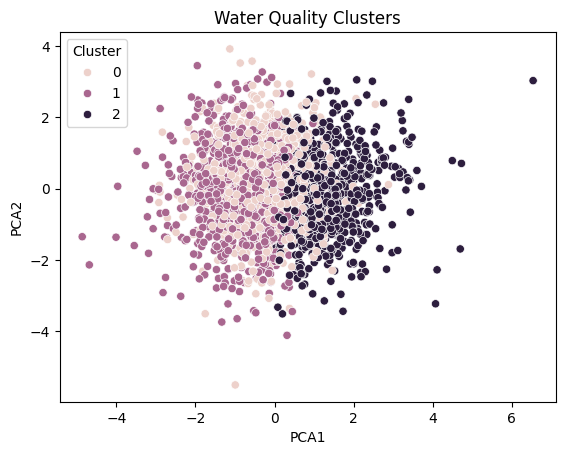

In [6]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]

sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df)
plt.title("Water Quality Clusters")
plt.show()

In [7]:
df.to_csv("../outputs/clustering_results.csv", index=False)